LABORATORIO 1

EXERCISE 01.1

Questa esercitazione ha l'obiettivo di testare il generatore di numeri casuali lineare congruenziale, (Lehmer 1951). Questo algoritmo sarà la base di ogni applicazione Monte Carlo, in quanto tramite strumenti della teoria, ci permetterà di generare numeri casuali distribuiti con una qualunque distribuzione di probabilità. Nello specifico l'algoritmo genera un numero intero secondo la funzione:
$$
i_{n+1}=(ai_n+c) mod m
$$
dove a, c, m sono parametri interi. L'importanza di questo approccio è che possiamo generare una sequenza che abbia, come limite superiore, una lunghezza di m numeri diversi tra loro. Questa tecnica però presenta dei problemi, come il fatto che i bit più bassi dei numeri generati dipendono fortemente da quelli del numero precedente generato a causa dell'operazione di resto. Inoltre si dimostra che i punti generati in questo modo, quando guardati a gruppi di k in uno spazio di dimensione k si distribuiscono su iperpiani di dimensione k-1. La soluzione è lo shuffle di Bays e Durham. Questo approccio risolve sia il problema di lunghezza che il problema di mancata uniformità. Dopodichè si genera un numero da 0 a 1 diidendo per m.

Ci interesserà testare quindi che il nostro generatore rappresenti effettivamente numeri distribuiti con una probabilità uniforme, andando a vedere quale sia il valor medio della sequenza e la sua varianza. Per numeri generati uniformemente:
$$
<x>=\int_0^1x dx = 1/2 \\
\sigma^2 = \int_0^1dx (x-<x>)^2 = \int_0^1dx(x-1/2)^2 = 1/12
$$

PREMESSA:
Le analisi statistiche riportate fanno uso della tecnica del data blocking. Questo è fondamentale perchè permette di valutare correttamente le proprietà di errore anche per sequenze di numeri che presentano una correlazione tra elementi. Nello specifico, il generatore Rannyu genera numeri che presentano una correlazione interna. Nel momento in cui vogliamo stimare l'errore o applicare il teorema del limite centrale, le ipotesi richiedono che la sequenza sia indipendente e identicamente distribuità. Questo non è vero nel caso del Rannyu, ma se prendiamo delle sequenze sufficentemente lunghe, più di quella che è la lunghezza di correlazione tra i dati, possiamo assumere come misura la media di questo blocco, e condurre l'analisi statistica. Per fare questo, dividiamo gli M step della simulazione Montecarlo in N blocchi, o ognuno di lunghezza L=M/N. Assumiamo quindi che la lunghezza dei tali blocchi sia sufficientemente grande a farsi che le correlazioni tra i blocchi siano nulle. Ogni blocco conterrà l'esito di una misura sia essa ottenuta mediando gli L step Montecarlo del blocco, si è essa ottenuta in altro modo (vedi esperimento di Buffon in cui in ogni blocco si eseguono n_step Montecarlo, e il risultato di ogni singolo blocco non è dato da un processo di media). Supponiamo che la misura di blocco sia $A_i$, allora possiamo stimare l'errore come deviazione standard sulla media progressiva
$$
\braket{A^2}\simeq \frac{1}{N} \sum_{i=1}^NA_i^2 \\
\braket{A}^2\simeq \bigg(\frac{1}{N} \sum_{i=1}^NA_i\bigg)^2 \\
\frac{\sigma}{\sqrt{N-1}}\simeq\sqrt{\frac{\braket{A^2}-\braket{A}^2}{N-1}}
$$

**IMPLEMENTATION**
The code is based on a function `void compute_prog_mean(const vector<double>& data, vector<double>& sum_prog, vector<double>& err_prog)` which perform data blocking methods taking as parameter the whole sequence of MC step, and the two container for the progressive mean and the square value of it.

In [118]:
import numpy as np
from scipy.stats import linregress

data_mean = np.loadtxt("./OUTPUT/meanvalue.out", skiprows=1)
data_variance = np.loadtxt("./OUTPUT/variance_value.out", skiprows=1)

In [119]:
x = data_mean[:, 0]
sum_prog_mean = data_mean[:, 1]
err_prog_mean = data_mean[:, 2]
sum_prog_var = data_variance[:, 1]
err_prog_var = data_variance[:, 2]


Exponent = -0.32965985507985385
Coefficient =  0.005166349426232118


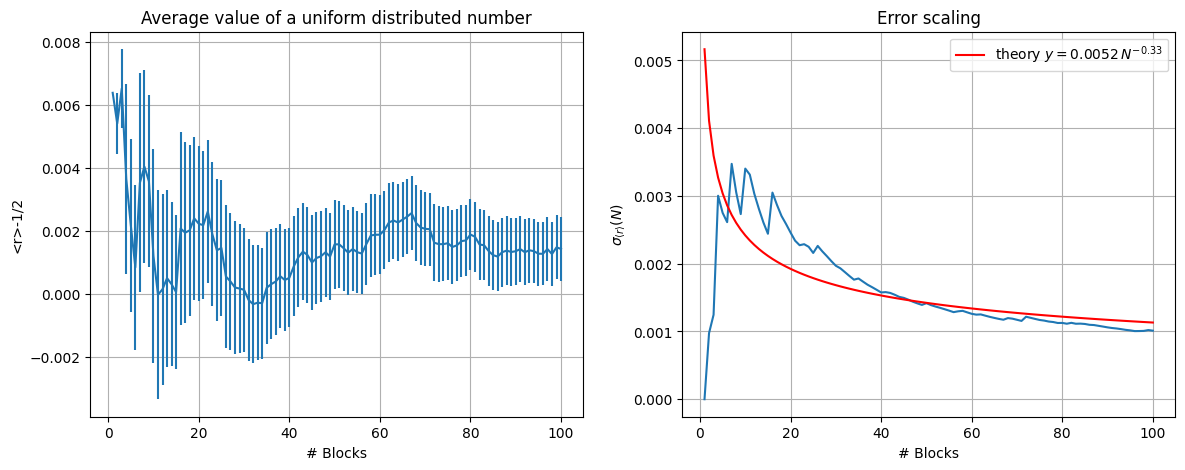

In [120]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].errorbar(x, sum_prog_mean-0.5, yerr=err_prog_mean)
ax[0].set_xlabel("# Blocks")
ax[0].set_ylabel("<r>-1/2")
ax[0].set_title("Average value of a uniform distributed number")
ax[0].grid(True)

X = np.log(x[1:])
Y = np.log(err_prog_mean[1:])
result = linregress(X, Y)
alpha = result.slope
intercept = result.intercept
A = np.exp(intercept)

print("Exponent =", alpha)
print("Coefficient = ", A)

ax[1].plot(x, err_prog_mean)
ax[1].plot(x, A*x**alpha, color='red', label=rf'theory $y={A:.4f}\, N^{{{alpha:.2f}}}$')
ax[1].set_xlabel("# Blocks")
ax[1].set_ylabel(r"$\sigma_{\langle r \rangle}(N)$")
ax[1].set_title("Error scaling")
ax[1].legend()
ax[1].grid(True)

Exponent = -0.5216130554149341
Coefficient =  0.0024380161566964547


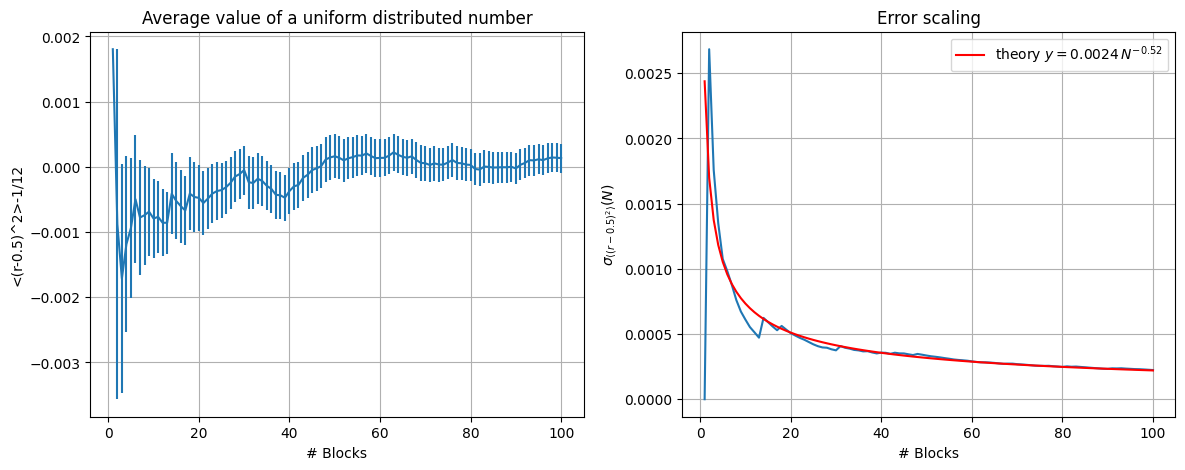

In [121]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].errorbar(x, sum_prog_var-1/12, yerr=err_prog_var)
ax[0].set_xlabel("# Blocks")
ax[0].set_ylabel("<(r-0.5)^2>-1/12")
ax[0].set_title("Average value of a uniform distributed number")
ax[0].grid(True)

Y = np.log(err_prog_var[1:])
result = linregress(X, Y)
alpha = result.slope
intercept = result.intercept
A = np.exp(intercept)

print("Exponent =", alpha)
print("Coefficient = ", A)

ax[1].plot(x, err_prog_var)
ax[1].plot(x, A*x**alpha, color='red', label=rf'theory $y={A:.4f}\, N^{{{alpha:.2f}}}$')
ax[1].set_xlabel("# Blocks")
ax[1].set_ylabel(r"$\sigma_{\langle (r-0.5)^2 \rangle}(N)$")
ax[1].set_title("Error scaling")
ax[1].legend()
ax[1].grid(True)

Si nota l'importanza di fare data blocking. Preso un numero di valori pari al numero di lanci, quando si fa l'operazione di media, questa non presenta il valore corretto, perchè la sequenza è generata da un algoritmo che lavora non correttamente in modo uniforme e che introduce delle correlazioni, con grosse oscillazioni delle barre di errore. Quando il numero di blocchi diventa considerevole e quindi iniziamo ad assumere una distribuzione identica e inidpendente tra i valori (Gaussiana dal CLT), ecco che il valor medio si stabilizza sul valore aspettato e le barre di errore scalano in modo migliore. Ed infatti si riscontra che, se ogni variabile generata $x_{il}$ uniformemente, e quindi con valor medio di 1/2, viene definita
$$
A_i=\frac{1}{L}\sum_{l=1}^Lx_{il}
$$
La sua media tende a 1/2 e la sua varianza a 1/12 per il CLT.

**Pearson Test**
Inoltre si sottopone il generatore al test del $\chi^2$ di Pearson. Questo test permette di valutare quale sia la probabilità che un numero non sia realmente estratto da una certa distribuzione. L'oobiettivo sarà quindi mostrare che questa probabilità è bassa. Per darlo si valuta l'errore tra le osservazioni e i valori aspettati. Per fare questo, dividiamo l'intervallo [0, 1] in Q identici sottointervalli. All'ora in ogni sottointervallo il numero di eventi attesi dopo n lanci è n/Q. Per farlo utilizziamo Q = 100, n=10000, se il numero di osservazioni tende a n/Q dovremmo aspettarci un $\chi^2\simeq 100$.
Per ogni blocco quindi si calcola il chi quadro e si va a vedere come è distribuito tramite un istogramma. Per valutare l'istogramma prodotto, dobbiamo vedere che l'istogramma prodotto coincida con un valore più probabile del $\chi^2$ sia attorno al 100.

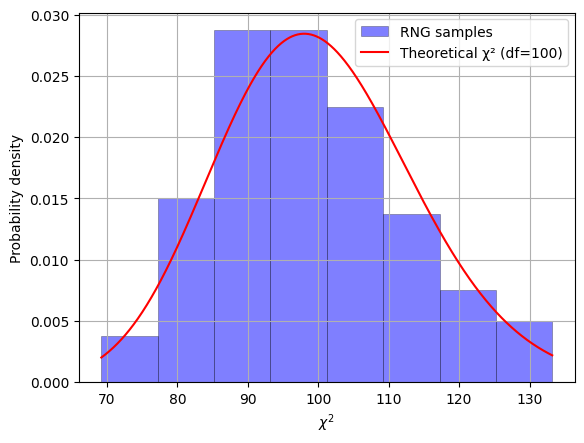

Valore <X2> = :  98.78560000000002


In [122]:
import scipy.stats as stats
from scipy.stats import norm, cauchy #theory fit

chi = np.loadtxt("./OUTPUT/X2.out")
plt.hist(chi, bins='auto', density=True, color='blue', alpha=0.5, edgecolor='black', linewidth=0.4, label='RNG samples')

Q = 100
num_lanci = 1000
x = np.linspace(min(chi), max(chi), num_lanci)
plt.plot(x, stats.chi2.pdf(x, Q), 'r-', label=f'Theoretical χ² (df={Q})')
plt.xlabel(r"$\chi^2$")
plt.ylabel("Probability density")
plt.legend()
plt.grid(True)
plt.show()
print("Valore <X2> = : ", np.mean(chi))

**EXERCISE 01.2**

Dopo aver fatto questa prima serie di test, verifichiamo il teorema del limite centrale. Lo facciamo sia per numeri generati uniformemente che per numeri casuali generati con distribuzioni di probabilità differenti, sempre a partire dal Rannyu. Nello specifico useremo distribuzioni di probabilità esponenziale e Lorentziana, per valutare due aspetti:
- Le sequenze generate con distribuzioni di probabilità ottenute tramite il metodo della cumulativa con il generatore uniforme uniforme, tendono ad una distribuzione gaussiana quando sommate.
- Se la distribuzione di partenza è una distribuzione di Levy, essa raprresenta un bacino di attrazione per densità di probabilità

**Da densità uniforme a generica tramite il metodo della cumulativa**

Tramite la definizione di funzione cumulativa F si può generare numeri distribuiti secondo una certa distribuzione a partire da quella uniforme. Infatti si dimostra che se y=F(x) dove x ha una certa $p_x(x)$, la variabile y è uniformemente distribuita tra 0 e 1. Di conseguenza se si è in grado di calcolare e invertire la cumulativa, possiamo generare x=F(y) con y uniforme [0, 1] con distribuzione $p_x(x)$. Testiamo quindi numeri distribuiti esponenzialmente e con distribuzione Lorentziana

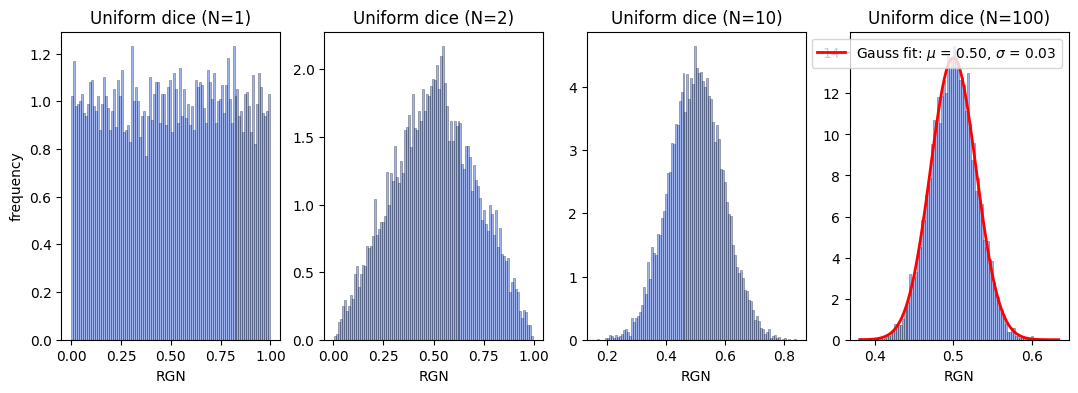

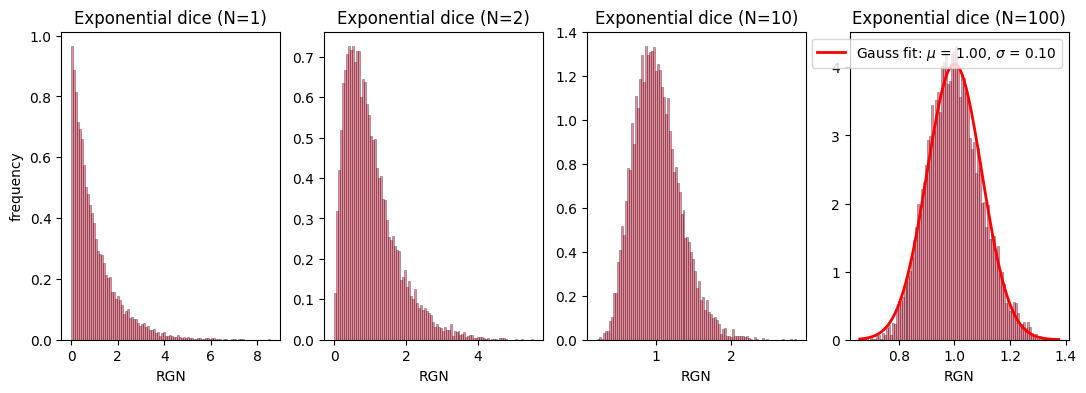

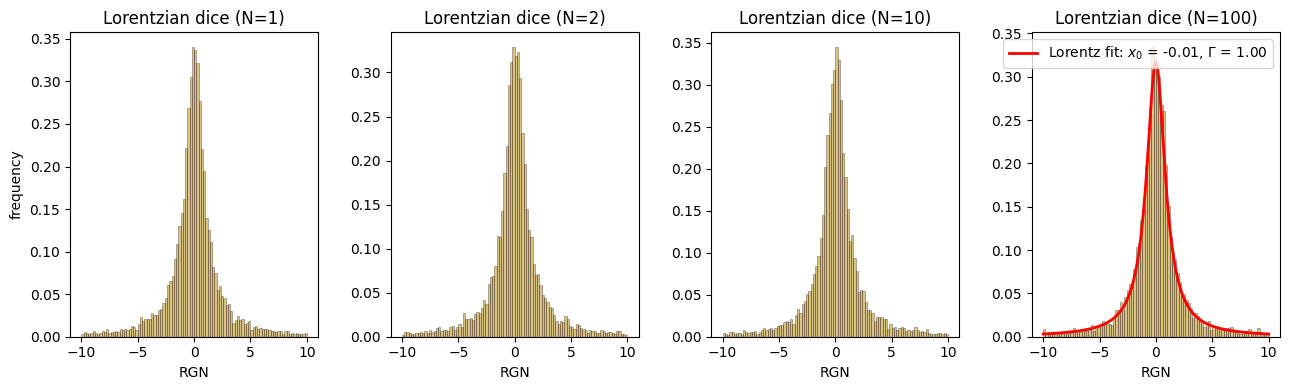

In [123]:
import numpy as np
import matplotlib.pyplot as plt

histo_uni = np.loadtxt("./OUTPUT/S_uniform.out")
histo_exp = np.loadtxt("./OUTPUT/S_exp.out")
histo_lor = np.loadtxt("./OUTPUT/S_Lorentz.out")

N = histo_uni[:, 0]
Ns = np.unique(N).astype(int)
num_val = int(len(N) / len(Ns))
bins = 100
fig, axes = plt.subplots(1, len(Ns), figsize=(13, 4))
for i in range(len(Ns)):
    values = histo_uni[i * num_val : (i + 1) * num_val, 1]
    ax = axes[i]
    ax.hist(values, bins=bins, density=True, color='royalblue', alpha=0.5, edgecolor='black', linewidth=0.4)
    ax.set_xlabel("RGN")
    axes[0].set_ylabel("frequency")
    ax.set_title(f"Uniform dice (N={Ns[i]})")
    mu_u, sigma_u = norm.fit(values) #calcola parametri per il fit
    x_u = np.linspace(min(values), max(values), 100)
axes[3].plot(x_u, norm.pdf(x_u, mu_u, sigma_u), 'r-', lw=2, label=rf'Gauss fit: $\mu$ = {format(mu_u, ".2f")}, $\sigma$ = {format(sigma_u, ".2f")}')
axes[3].legend()

fig, axes = plt.subplots(1, len(Ns), figsize=(13, 4))
for i in range(len(Ns)):
    values = histo_exp[i * num_val : (i + 1) * num_val, 1]
    ax = axes[i]
    ax.hist(values, bins=bins, density=True, color='crimson', alpha=0.5, edgecolor='black', linewidth=0.4)
    ax.set_xlabel("RGN")
    axes[0].set_ylabel("frequency")
    ax.set_title(f"Exponential dice (N={Ns[i]})")
    mu_e, sigma_e = norm.fit(values) #calcola parametri per il fit
    x_e = np.linspace(min(values), max(values), 100)
axes[3].plot(x_e, norm.pdf(x_e, mu_e, sigma_e), 'r-', lw=2, label=rf'Gauss fit: $\mu$ = {format(mu_e, ".2f")}, $\sigma$ = {format(sigma_e, ".2f")}')
axes[3].legend()

fig, axes = plt.subplots(1, len(Ns), figsize=(13, 4))
for i in range(len(Ns)):
    values = histo_lor[i * num_val : (i + 1) * num_val, 1]
    ax = axes[i]
    ax.hist(values, bins=bins, range=(-10,10), density=True, color='darkgoldenrod', alpha=0.5, edgecolor='black', linewidth=0.4)
    ax.set_xlabel("RGN")
    axes[0].set_ylabel("frequency")
    ax.set_title(f"Lorentzian dice (N={Ns[i]})")
    params = cauchy.fit(values)
    x_c = np.linspace(-10, 10, 1000)
axes[3].plot(x_c, cauchy.pdf(x_c, *params), 'r-', lw=2, label=rf"Lorentz fit: $x_0$ = {format(params[0], '.2f')}, $\Gamma$ = {format(params[1], '.2f')}")
axes[3].legend()

plt.tight_layout()
plt.show()


**EXERCISE 01.3 (BUFFON EXPERIMENT)**

Si applica il metodo Monte-Carlo a un esperimento per stimare π. Si utilizza un ago di lunghezza L e si valuta la probabilità che intersechi una linea tra le due a distanza d (con d>L). Si ottiene:
$$
\pi = \frac{2LN_{thr}}{N_{hit}d}
$$
Per non utilizzare direttamente il π nel suo calcolo, generiamo l'angolo prendendo due punti che stiano sul cerchio e dividendo poi la coordinata verticale per il raggio.

**IMPLEMENTATION**

Il codice utilizzato si basa su una funzione `double buffon_exp(double d, double l, int needle_throws, Random& r)`che esegue il singolo esperimento e calcola un valore di blocco per π. Nello specifico, generiamo un numero casuale $x\in(0, d/2)$ che rappresenta il centro dell'ago. Invece per generare l'angolo non usiamo direttamente il valore di π ma generiamo punti el cerchio unitario. Il criterio per cui l'ago colpisce la linea è:
$$
x\leq\frac{L}{2}|sin(\theta)|=\frac{L}{2}\bigg|\frac{y}{x^2+y^2}\bigg|
$$
in cui prendiamo il modulo per simmetria del problema.
Dopodichè si analizzano gli errori e il valor medio facendo una somma progressiva a blocchi. L'errore viene sempre calcolato tramite l'apposita funzione `double error(double av, double av2, int n)`

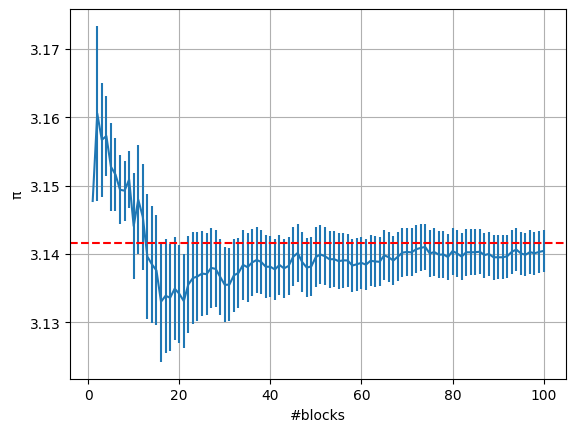

In [124]:
datapi = np.loadtxt("./OUTPUT/buffon.out", skiprows=1)

Num_blocks = datapi[:, 0]
PI = datapi[:, 1]
err = datapi[:, 2]

plt.errorbar(Num_blocks, PI, yerr=err, label="buuffon needle")
plt.axhline(y=np.pi, ls='--', color='red')
plt.xlabel("#blocks")
plt.ylabel("π")
plt.grid(True)
plt.show()
